# Customer Segmentation Analysis


**Objective:**

Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

**Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

**load the dataset**

In [ ]:
df = pd.read_csv("data.csv", encoding="latin-1")

**Inspect the dataset**

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.duplicated().sum()

np.int64(5268)

**Removing customers with missing CustomerID**

In [ ]:
df = df.dropna(subset=["CustomerID"])

In [ ]:
df.shape

(406829, 8)

**Removing duplicate transactions**

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(401604, 8)

**Convert InvoiceDate**

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
df["InvoiceDate"].head()

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


**Checking cancelled transactions**

In [ ]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(8872)

In [ ]:
df = df.dropna(subset=["CustomerID"])

In [ ]:
df.shape

(401604, 8)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(401604, 8)

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
df["InvoiceDate"].head()

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


In [ ]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(8872)

**Removing cancelled transactions**

In [ ]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [ ]:
df.shape

(392732, 8)

**Checking invalid quantities**

In [ ]:
df["Quantity"].describe()

,Quantity
count,392732.000000
mean,13.153718
std,181.588420
min,1.000000
25%,2.000000
50%,6.000000
75%,12.000000
max,80995.000000


In [ ]:
(df["Quantity"] <= 0).sum()

np.int64(0)

**Checking invalid prices**

In [ ]:
df["UnitPrice"].describe()

,UnitPrice
count,392732.000000
mean,3.125596
std,22.240725
min,0.000000
25%,1.250000
50%,1.950000
75%,3.750000
max,8142.750000


In [ ]:
(df["UnitPrice"] <= 0).sum()

np.int64(40)

**Removing invalid prices**

In [ ]:
df = df[df["UnitPrice"] > 0]

In [ ]:
df.shape

(392692, 8)

**Creating Total Price**

**Calculate Total Purchase Value**

The total purchase value for each transaction is calculated by multiplying the quantity purchased by the unit price. This feature will be used to calculate the Monetary component of the RFM analysis.

In [ ]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
df[["Quantity", "UnitPrice", "TotalPrice"]].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


**Final Cleaning**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalPrice,0


# **RFM Analysis**

RFM analysis is a useful way to evaluate customers' buying behaviour based on three indicators – Recency, Frequency, and Monetary value.

Recency refers to the time passed since the customer's last purchase. Frequency refers to the number of different invoices pertaining to that customer.  Finally, Monetary refers to the total amounts customers have spent.

In [ ]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-10 12:50:00


**RMF Table**

In [ ]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

In [ ]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [ ]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


**RFM statistics**

In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [ ]:
print("Average Recency:", rfm["Recency"].mean())
print("Average Frequency:", rfm["Frequency"].mean())
print("Average Monetary Value:", rfm["Monetary"].mean())

Average Recency: 92.53642231443061
Average Frequency: 4.272014753342554
Average Monetary Value: 2048.688080682342


**Feature Selection**

### **Feature Selection**
The three RFM metrics, namely Recency, Frequency, and Monetary value are chosen as the significant behavioural features to segment the customers.

These features reflect when customers last made a purchase, how frequently they buy, and how much they spend.

In [ ]:
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

rfm_features.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


### **Transformating Features**
The RFM variables have different ranges. The StandardScaler is used to transform all input features to have values that fall within the same range.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


In [ ]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,2.293130e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.276151e-01
25%,-7.453445e-01,-4.250965e-01,-1.939190e-01
50%,-4.153533e-01,-2.951776e-01,-1.536162e-01
75%,4.946227e-01,9.457903e-02,-4.319704e-02
max,2.814561e+00,2.659803e+01,3.096074e+01


**Elbow Method**

**Finding the Best Number of Clusters**

For K-means clustering, we use the Elbow method to find the best number of clusters. We compute the inertia – which is the sum of squared errors within each cluster – for various values of K. We then choose the appropriate number of clusters where the rate of decrease in inertia starts to slow.

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

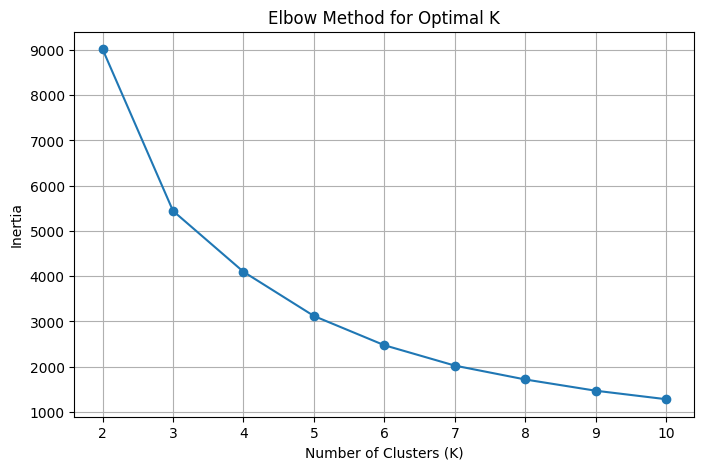

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(K_range)
plt.grid(True)

plt.show()

## **K-Means Clustering**
According to the Elbow Method, there were four clusters selected for the identification of customer segments. The change in inertia is not so significant after number K which may validate our choice of using four clusters for the analysis.

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [ ]:
rfm["Cluster"].value_counts().sort_index()

,count
Cluster,
0,3054
1,1067
2,13
3,204


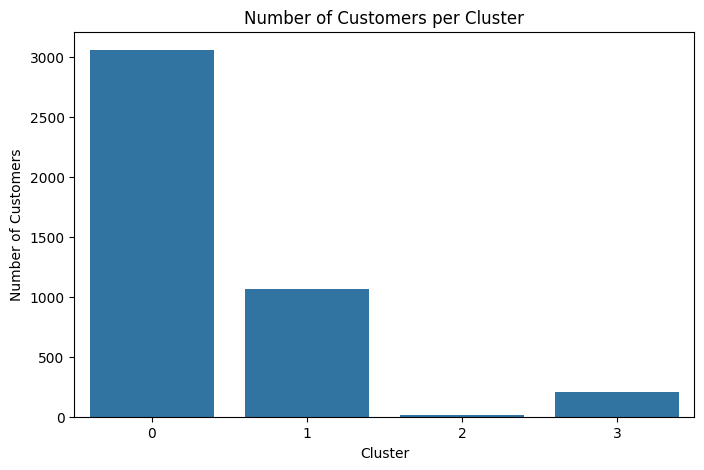

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=rfm, x="Cluster")

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

## **Cluster Profiling**

Once the cluster is created, the data is profiled by taking the average Recency, Frequency, and Monetary data for each cluster. This data can provide insight into how customers behave when buying products.

In [ ]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


**Frequency vs Monetary**

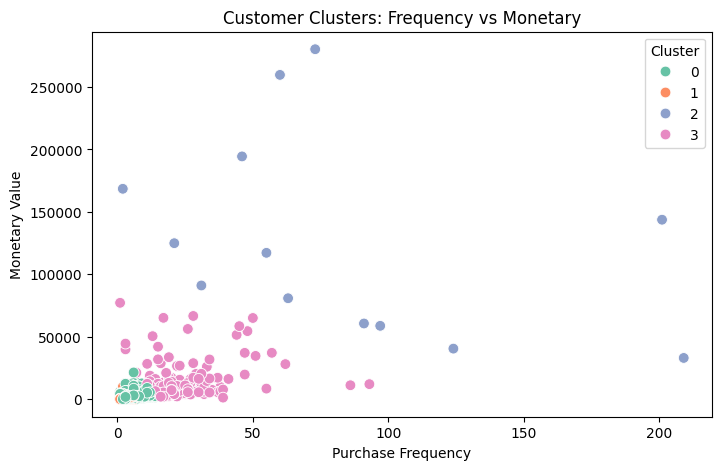

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=60
)

plt.title("Customer Clusters: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")

plt.show()

**Recency vs Monetary**

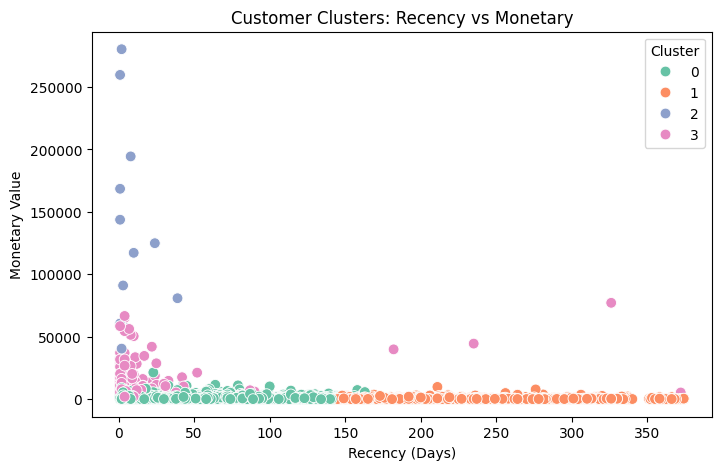

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=60
)

plt.title("Customer Clusters: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")

plt.show()

## **Interpretation of Customer Segments**
According to the average values for Recency, Frequency, and Monetary, the four clusters can be interpreted as follows:

Cluster 0 – Regular Customers: Recency, Frequency, and Monetary values all moderate.

Cluster 1 – At-Risk / Low-Value Customers: High Recency value but low frequency and Monetary values.

Cluster 2 – VIP / High-Value Customers: Recently made frequent purchases with higher spending level.

Cluster 3 – Loyal, High-Value Customers: Recent purchases along with high frequency and expenditure.

In [ ]:
cluster_names = {
    0: "Regular Customers",
    1: "At-Risk / Low-Value Customers",
    2: "VIP / High-Value Customers",
    3: "Loyal High-Value Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal High-Value Customers
12347.0,2,7,4310.00,0,Regular Customers
12348.0,75,4,1797.24,0,Regular Customers
12349.0,19,1,1757.55,0,Regular Customers
12350.0,310,1,334.40,1,At-Risk / Low-Value Customers


**Final segment summary**

In [ ]:
segment_summary = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().round(2)

segment_summary

,Recency,Frequency,Monetary
Segment,,,
At-Risk / Low-Value Customers,248.08,1.55,478.85
Loyal High-Value Customers,15.50,22.33,12690.50
Regular Customers,43.70,3.68,1353.63
VIP / High-Value Customers,7.38,82.54,127187.96


In [ ]:
segment_counts = rfm["Segment"].value_counts()

segment_counts

,count
Segment,
Regular Customers,3054
At-Risk / Low-Value Customers,1067
Loyal High-Value Customers,204
VIP / High-Value Customers,13


## **Marketing Suggestions**

Cluster 0 – Regular Customers
These are customers who show average buying behavior and expenditures.
Suggested action:
Adopt the use of individualized product suggestions.
Provide time-limited discounts to enhance transaction frequency.
Motivate customers to progress toward the loyal category.

Cluster 1 - Low-Value / At-Risk Customers
These customers haven't bought anything recently, have low buying frequency and low monetary value.
Suggested action:
Implement win-back email campaigns.
Provide individual discounts or incentives.
Remind customers about available products.

Cluster 2 - High-Value / VIP Customers
This group of customers buy very well, greatly exceeds this group in expenditures, and recently bought something.
Suggested action:
Implement the VIP loyalty program.
Provide early access to product launches.
Provide exclusive advantages instead of big discounts.

Cluster 3 - Loyal High-Value Customers
This group consists of customers who buy often, spend a lot, and have bought things recently.
Suggested action:
Implement loyalty programs.
Provide personalized suggestions.
Encourage customers to buy even more.

## **conclusion**
The combination of RFM analysis with K-means clustering has enabled the segmentation of the entire e-commerce consumer database into four distinct groups according to their buying behaviours.
The analysis revealed the presence of a VIP/High-value segment with a high frequency of purchases and high purchasing power as well.
These segments will allow the company to implement peacekeeping measures regarding the customers since the company can develop the unique marketing strategy to communicate with customers depending on their segment.